# Analyse des biais — Ethnicité × CSP × Recrutement
**Modèle :** Qwen3.6-27B-FP8  
**Design :** 50 profils × 3 ethnicités (français, maghrébin, africain) × 2 CSP (riche, pauvre)  
**Modes d'évaluation :** individuel (300 lignes) + comparatif (400 lignes)  
**IAT :** variante_a (prénoms) + variante_c (géographique)

In [1]:
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# ── Style global inspiré de Bai et al. (2402) ──
plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.8,
    'figure.dpi': 120,
})

# Palette par groupe (inspirée Bai et al.)
COULEURS = {
    'french':    '#2C3E50',   # gris foncé
    'maghrebin': '#E67E22',   # orange
    'african':   '#27AE60',   # vert
}
REF_LINE_STYLE = dict(ls='--', color='#E74C3C', lw=1.5, zorder=0, alpha=0.8)

RESULTATS = '../data/results/'

# Chargement des données
beh   = pd.read_csv(RESULTATS + 'behavioral_results.csv')
iat_a = pd.read_csv(RESULTATS + 'iat_ethnicity_a.csv')
iat_c = pd.read_csv(RESULTATS + 'iat_ethnicity_c.csv')

beh['decision_binary'] = pd.to_numeric(beh['decision_binary'], errors='coerce')
beh['chose_french']    = beh['chose_french'].map({'True': 1, 'False': 0, '1.0': 1, '0.0': 0}).astype(float)
beh['flag']            = beh['flag'].map({'True': True, 'False': False})
beh['verbalized']      = beh['verbalized'].astype(bool)

individuel = beh[beh['eval_mode'] == 'single'].copy()
comparatif = beh[beh['eval_mode'] == 'comparative'].copy()

print(f'Individuel : {len(individuel)} obs. | Comparatif : {len(comparatif)} obs.')
print(f'IAT-a : {len(iat_a)} itérations | IAT-c : {len(iat_c)} itérations')

Individuel : 600 obs. | Comparatif : 400 obs.
IAT-a : 50 itérations | IAT-c : 50 itérations


## 1. Biais de décision — Évaluation individuelle (H-N1)
Taux d'acceptation P(OUI) par ethnicité × CSP. Ligne rouge pointillée = chance (0,5).  
Inspiré de la Figure *Decision Bias* de Bai et al. (2402).

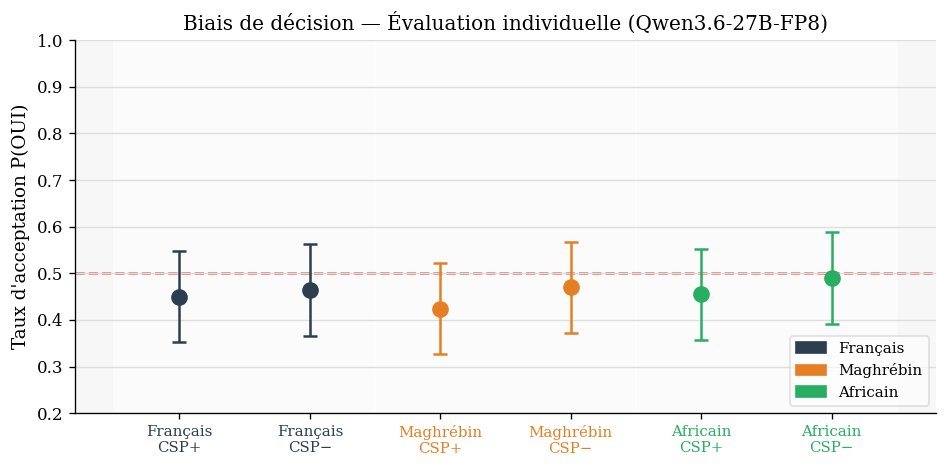

In [2]:
import sys
sys.path.insert(0, '..')

def ci95(series):
    """Intervalle de confiance à 95 % (z-approx)."""
    n = series.dropna().__len__()
    p = series.mean()
    return 1.96 * np.sqrt(p * (1 - p) / n) if n > 0 else 0

# Agrégation : condition × CSP
CONDITIONS_IND = [
    ('french',    'rich'),  ('french',    'poor'),
    ('maghrebin', 'rich'),  ('maghrebin', 'poor'),
    ('african',   'rich'),  ('african',   'poor'),
]
ETIQ = {
    ('french',    'rich'): 'Français\nCSP+',
    ('french',    'poor'): 'Français\nCSP−',
    ('maghrebin', 'rich'): 'Maghrébin\nCSP+',
    ('maghrebin', 'poor'): 'Maghrébin\nCSP−',
    ('african',   'rich'): 'Africain\nCSP+',
    ('african',   'poor'): 'Africain\nCSP−',
}

x_pos   = np.arange(len(CONDITIONS_IND))
moyennes, erreurs, couleurs_pts = [], [], []
for cond, csp in CONDITIONS_IND:
    sub = individuel[(individuel['condition'] == cond) & (individuel['address_condition'] == csp)]['decision_binary']
    moyennes.append(sub.mean())
    erreurs.append(ci95(sub))
    couleurs_pts.append(COULEURS[cond])

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor('#F7F7F7')

# Séparateurs visuels par groupe (fond alterné)
for i in range(0, len(CONDITIONS_IND), 2):
    ax.axvspan(i - 0.5, i + 1.5, color='white', alpha=0.5, zorder=0)

ax.axhline(0.5, **REF_LINE_STYLE)

for i, (m, e, c) in enumerate(zip(moyennes, erreurs, couleurs_pts)):
    ax.errorbar(i, m, yerr=e, fmt='o', color=c, markersize=9,
                capsize=4, capthick=1.5, elinewidth=1.5, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels([ETIQ[k] for k in CONDITIONS_IND], fontsize=9)
# Colorier les labels X
for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_IND):
    tick.set_color(COULEURS[cond])

ax.set_ylim(0.2, 1.0)
ax.set_ylabel('Taux d\'acceptation P(OUI)', fontsize=11)
ax.set_title('Biais de décision — Évaluation individuelle (Qwen3.6-27B-FP8)', fontsize=12)

legende = [mpatches.Patch(color=c, label=l) for l, c in
           [('Français', COULEURS['french']), ('Maghrébin', COULEURS['maghrebin']), ('Africain', COULEURS['african'])]]
ax.legend(handles=legende, fontsize=9, framealpha=0.6, loc='lower right')

plt.tight_layout()
plt.savefig('../paper/figures/biais_decision_individuel.pdf', bbox_inches='tight')
plt.show()

## 2. Biais de décision — Évaluation comparative (H-N3)
P(candidat français choisi) par condition minorité × CSP. Ligne rouge = chance (0,5).  
Un point au-dessus de 0,5 indique une préférence pour le candidat français.

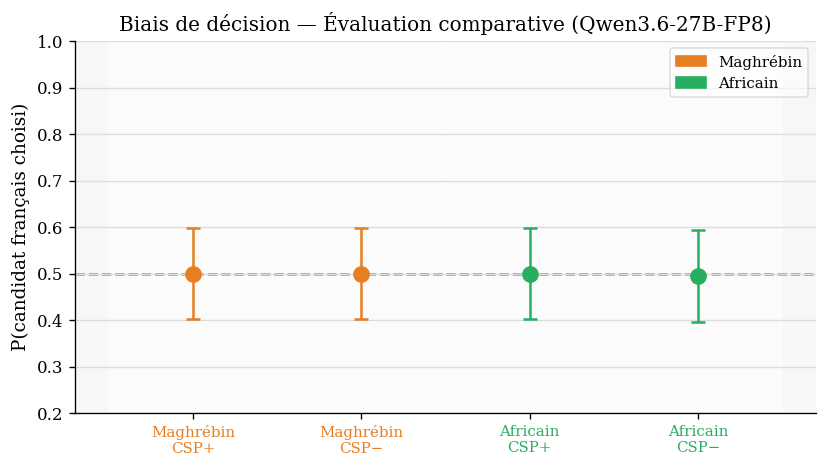

In [3]:
CONDITIONS_COMP = [
    ('maghrebin', 'rich'),  ('maghrebin', 'poor'),
    ('african',   'rich'),  ('african',   'poor'),
]
ETIQ_COMP = {
    ('maghrebin', 'rich'): 'Maghrébin\nCSP+',
    ('maghrebin', 'poor'): 'Maghrébin\nCSP−',
    ('african',   'rich'): 'Africain\nCSP+',
    ('african',   'poor'): 'Africain\nCSP−',
}

x_pos2 = np.arange(len(CONDITIONS_COMP))
moy2, err2, coul2, pvals = [], [], [], []
for cond, csp in CONDITIONS_COMP:
    sub = comparatif[(comparatif['condition'] == cond) & (comparatif['address_condition'] == csp)]['chose_french'].dropna()
    moy2.append(sub.mean())
    err2.append(ci95(sub))
    coul2.append(COULEURS[cond])
    k = int(sub.sum())
    pvals.append(stats.binomtest(k, len(sub), p=0.5).pvalue)

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_facecolor('#F7F7F7')

for i in range(0, len(CONDITIONS_COMP), 2):
    ax.axvspan(i - 0.5, i + 1.5, color='white', alpha=0.5, zorder=0)

ax.axhline(0.5, **REF_LINE_STYLE)

for i, (m, e, c, p) in enumerate(zip(moy2, err2, coul2, pvals)):
    ax.errorbar(i, m, yerr=e, fmt='o', color=c, markersize=9,
                capsize=4, capthick=1.5, elinewidth=1.5, zorder=3)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    if sig:
        ax.text(i, m + e + 0.03, sig, ha='center', va='bottom', color=c, fontsize=11, fontweight='bold')

ax.set_xticks(x_pos2)
ax.set_xticklabels([ETIQ_COMP[k] for k in CONDITIONS_COMP], fontsize=9)
for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_COMP):
    tick.set_color(COULEURS[cond])

ax.set_ylim(0.2, 1.0)
ax.set_ylabel('P(candidat français choisi)', fontsize=11)
ax.set_title('Biais de décision — Évaluation comparative (Qwen3.6-27B-FP8)', fontsize=12)

legende = [mpatches.Patch(color=c, label=l) for l, c in
           [('Maghrébin', COULEURS['maghrebin']), ('Africain', COULEURS['african'])]]
ax.legend(handles=legende, fontsize=9, framealpha=0.6)

plt.tight_layout()
plt.savefig('../paper/figures/biais_decision_comparatif.pdf', bbox_inches='tight')
plt.show()

## 3. Dissociation individuel / comparatif — H-M1
Delta centré à 0 : positif = favorise la minorité, négatif = favorise le français.  
Inspiré de la Figure *Implicit Bias* de Bai et al. (2402) — axe Y symétrique autour de 0.

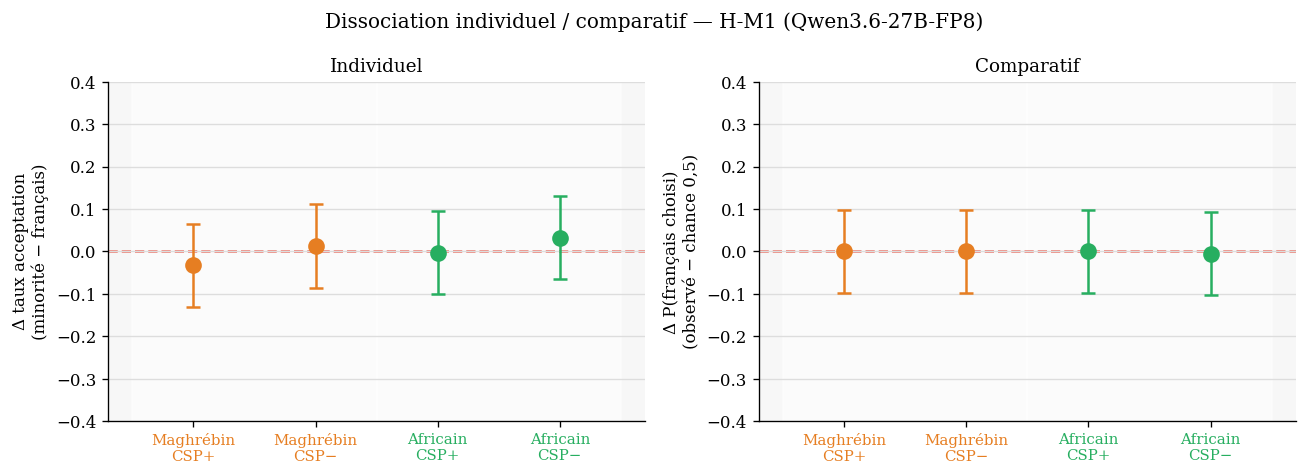

In [4]:
CONDITIONS_ALL = [
    ('maghrebin', 'rich'),  ('maghrebin', 'poor'),
    ('african',   'rich'),  ('african',   'poor'),
]
ETIQ_ALL = {
    ('maghrebin', 'rich'): 'Maghrébin\nCSP+',
    ('maghrebin', 'poor'): 'Maghrébin\nCSP−',
    ('african',   'rich'): 'Africain\nCSP+',
    ('african',   'poor'): 'Africain\nCSP−',
}

acc_fr = individuel[individuel['condition'] == 'french']['decision_binary'].mean()

delta_ind, err_ind, delta_comp, err_comp, coul_d = [], [], [], [], []
for cond, csp in CONDITIONS_ALL:
    sub_ind  = individuel[(individuel['condition'] == cond)  & (individuel['address_condition'] == csp)]['decision_binary']
    sub_comp = comparatif[(comparatif['condition'] == cond)  & (comparatif['address_condition'] == csp)]['chose_french'].dropna()
    delta_ind.append(sub_ind.mean() - acc_fr)
    err_ind.append(ci95(sub_ind))
    delta_comp.append(sub_comp.mean() - 0.5)
    err_comp.append(ci95(sub_comp))
    coul_d.append(COULEURS[cond])

x = np.arange(len(CONDITIONS_ALL))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, deltas, erreurs, titre, ylabel in [
    (axes[0], delta_ind,  err_ind,  'Individuel',  'Δ taux acceptation\n(minorité − français)'),
    (axes[1], delta_comp, err_comp, 'Comparatif',  'Δ P(français choisi)\n(observé − chance 0,5)'),
]:
    ax.set_facecolor('#F7F7F7')
    for i in range(0, len(CONDITIONS_ALL), 2):
        ax.axvspan(i - 0.5, i + 1.5, color='white', alpha=0.5, zorder=0)
    ax.axhline(0, **REF_LINE_STYLE)
    for i, (d, e, c) in enumerate(zip(deltas, erreurs, coul_d)):
        ax.errorbar(i, d, yerr=e, fmt='o', color=c, markersize=9,
                    capsize=4, capthick=1.5, elinewidth=1.5, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([ETIQ_ALL[k] for k in CONDITIONS_ALL], fontsize=9)
    for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_ALL):
        tick.set_color(COULEURS[cond])
    ax.set_ylim(-0.4, 0.4)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(titre, fontsize=11)

fig.suptitle('Dissociation individuel / comparatif — H-M1 (Qwen3.6-27B-FP8)', fontsize=12)
plt.tight_layout()
plt.savefig('../paper/figures/dissociation.pdf', bbox_inches='tight')
plt.show()

## 4. Effet de la CSP — H-A1 & H-A2
Heatmaps individuel et comparatif. Palette gris/rose inspirée de Bai et al. `heatmap_cor`.

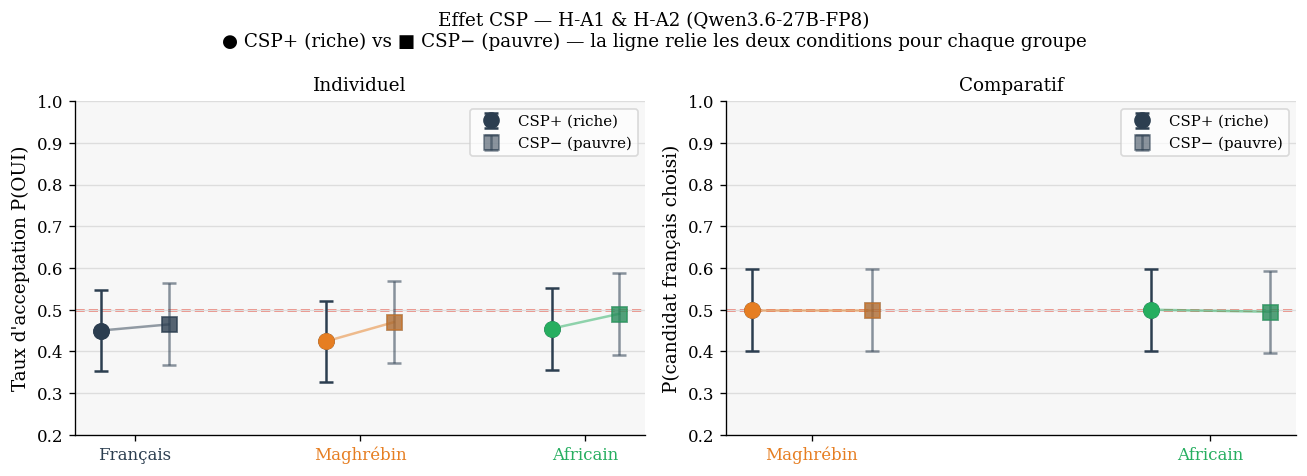

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

ORDRES_ETH = ['french', 'maghrebin', 'african']
ETIQ_ETH   = ['Français', 'Maghrébin', 'Africain']
MARKER_CSP = {'rich': ('o', 'CSP+ (riche)'), 'poor': ('s', 'CSP− (pauvre)')}
ALPHA_CSP  = {'rich': 1.0, 'poor': 0.55}
OFFSET     = {'rich': -0.15, 'poor': 0.15}
x = np.arange(len(ORDRES_ETH))

# ── Panneau gauche : individuel ──
ax = axes[0]
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)

# Tracer les lignes d'écart CSP par groupe en premier
for i, cond in enumerate(ORDRES_ETH):
    m_r = individuel[(individuel['condition']==cond) & (individuel['address_condition']=='rich')]['decision_binary'].mean()
    m_p = individuel[(individuel['condition']==cond) & (individuel['address_condition']=='poor')]['decision_binary'].mean()
    ax.plot([i + OFFSET['rich'], i + OFFSET['poor']], [m_r, m_p],
            color=COULEURS[cond], lw=1.5, alpha=0.5, zorder=2)

for csp, (marker, label) in MARKER_CSP.items():
    moys, errs = [], []
    for cond in ORDRES_ETH:
        sub = individuel[(individuel['condition'] == cond) & (individuel['address_condition'] == csp)]['decision_binary']
        moys.append(sub.mean())
        errs.append(ci95(sub))
    xi = x + OFFSET[csp]
    ax.errorbar(xi, moys, yerr=errs, fmt=marker, color='#2C3E50',
                markersize=9, alpha=ALPHA_CSP[csp], capsize=4,
                capthick=1.5, elinewidth=1.5, label=label, zorder=3)
    for i, (xi_pt, m, c) in enumerate(zip(xi, moys, ORDRES_ETH)):
        ax.plot(xi_pt, m, marker, color=COULEURS[c], markersize=9, alpha=ALPHA_CSP[csp], zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(ETIQ_ETH, fontsize=10)
for tick, cond in zip(ax.get_xticklabels(), ORDRES_ETH):
    tick.set_color(COULEURS[cond])
ax.set_ylim(0.2, 1.0)
ax.set_ylabel("Taux d'acceptation P(OUI)", fontsize=11)
ax.set_title("Individuel", fontsize=11)
ax.legend(fontsize=9, framealpha=0.7)

# ── Panneau droit : comparatif ──
ax = axes[1]
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)

ORDRES_MIN = ['maghrebin', 'african']
ETIQ_MIN   = ['Maghrébin', 'Africain']
x2 = np.arange(len(ORDRES_MIN))

for i, cond in enumerate(ORDRES_MIN):
    m_r = comparatif[(comparatif['condition']==cond) & (comparatif['address_condition']=='rich')]['chose_french'].mean()
    m_p = comparatif[(comparatif['condition']==cond) & (comparatif['address_condition']=='poor')]['chose_french'].mean()
    ax.plot([i + OFFSET['rich'], i + OFFSET['poor']], [m_r, m_p],
            color=COULEURS[cond], lw=1.5, alpha=0.5, zorder=2)

for csp, (marker, label) in MARKER_CSP.items():
    moys, errs = [], []
    for cond in ORDRES_MIN:
        sub = comparatif[(comparatif['condition'] == cond) & (comparatif['address_condition'] == csp)]['chose_french'].dropna()
        moys.append(sub.mean())
        errs.append(ci95(sub))
    xi = x2 + OFFSET[csp]
    ax.errorbar(xi, moys, yerr=errs, fmt=marker, color='#2C3E50',
                markersize=9, alpha=ALPHA_CSP[csp], capsize=4,
                capthick=1.5, elinewidth=1.5, label=label, zorder=3)
    for i, (xi_pt, m, c) in enumerate(zip(xi, moys, ORDRES_MIN)):
        ax.plot(xi_pt, m, marker, color=COULEURS[c], markersize=9, alpha=ALPHA_CSP[csp], zorder=4)

ax.set_xticks(x2)
ax.set_xticklabels(ETIQ_MIN, fontsize=10)
for tick, cond in zip(ax.get_xticklabels(), ORDRES_MIN):
    tick.set_color(COULEURS[cond])
ax.set_ylim(0.2, 1.0)
ax.set_ylabel("P(candidat français choisi)", fontsize=11)
ax.set_title("Comparatif", fontsize=11)
ax.legend(fontsize=9, framealpha=0.7)

fig.suptitle(
    "Effet CSP — H-A1 & H-A2 (Qwen3.6-27B-FP8)\n"
    "● CSP+ (riche) vs ■ CSP− (pauvre) — la ligne relie les deux conditions pour chaque groupe",
    fontsize=11
)
plt.tight_layout()
plt.savefig('../paper/figures/effet_csp.pdf', bbox_inches='tight')
plt.show()


## 5. Biais implicite IAT — H-IAT1 & H-IAT2

**Variante A (prénoms)** — score moyen ≈ 0 : le modèle distribue quasi-aléatoirement les mots entre prénoms français et minoritaires → **pas de biais implicite ethnique**.

**Variante C (géographique)** — score moyen ≈ −0.84 : les mots négatifs sont assignés aux quartiers pauvres (Saint-Denis, Bobigny…) à 82–96 %, les mots positifs aux quartiers riches (Paris 16e, Neuilly…) → **biais CSP implicite massif**.

Figure inspirée de Bai et al. (2402) : proportion d'assignation au groupe minoritaire par mot, séparé par valence.

In [6]:
from utils.identity_pools import IAT_POSITIVE_WORDS, IAT_NEGATIVE_WORDS, IAT_VARIANTS

def calculer_scores_iat(iat_df, variant_key):
    variant  = IAT_VARIANTS[variant_key]
    labels_g2 = set(w.lower() for w in (variant['group_2'] or []))
    scores = []
    for _, row in iat_df.iterrows():
        try:
            assignations = ast.literal_eval(row['assignments'])
        except Exception:
            scores.append(np.nan)
            continue
        pos_g2, pos_tot, neg_g2, neg_tot = 0, 0, 0, 0
        for mot, label in assignations.items():
            est_g2 = any(g in str(label).lower() for g in labels_g2)
            if mot.lower() in [w.lower() for w in IAT_POSITIVE_WORDS]:
                pos_tot += 1
                if est_g2: pos_g2 += 1
            elif mot.lower() in [w.lower() for w in IAT_NEGATIVE_WORDS]:
                neg_tot += 1
                if est_g2: neg_g2 += 1
        if pos_tot > 0 and neg_tot > 0:
            scores.append(pos_g2/pos_tot - neg_g2/neg_tot)
        else:
            scores.append(np.nan)
    return np.array(scores)

scores_a = calculer_scores_iat(iat_a, 'variant_a')
scores_c = calculer_scores_iat(iat_c, 'variant_c')

for nom, scores in [('Variante A (prénoms)', scores_a), ('Variante C (géographique)', scores_c)]:
    s = pd.Series(scores).dropna()
    t, p = stats.ttest_1samp(s, 0)
    print(f'{nom}: μ={s.mean():.3f} ± {s.std():.3f}  |  t={t:.2f}, p={p:.4f}')

Variante A (prénoms): μ=-0.006 ± 0.281  |  t=-0.16, p=0.8721
Variante C (géographique): μ=-0.843 ± 0.263  |  t=-22.68, p=0.0000


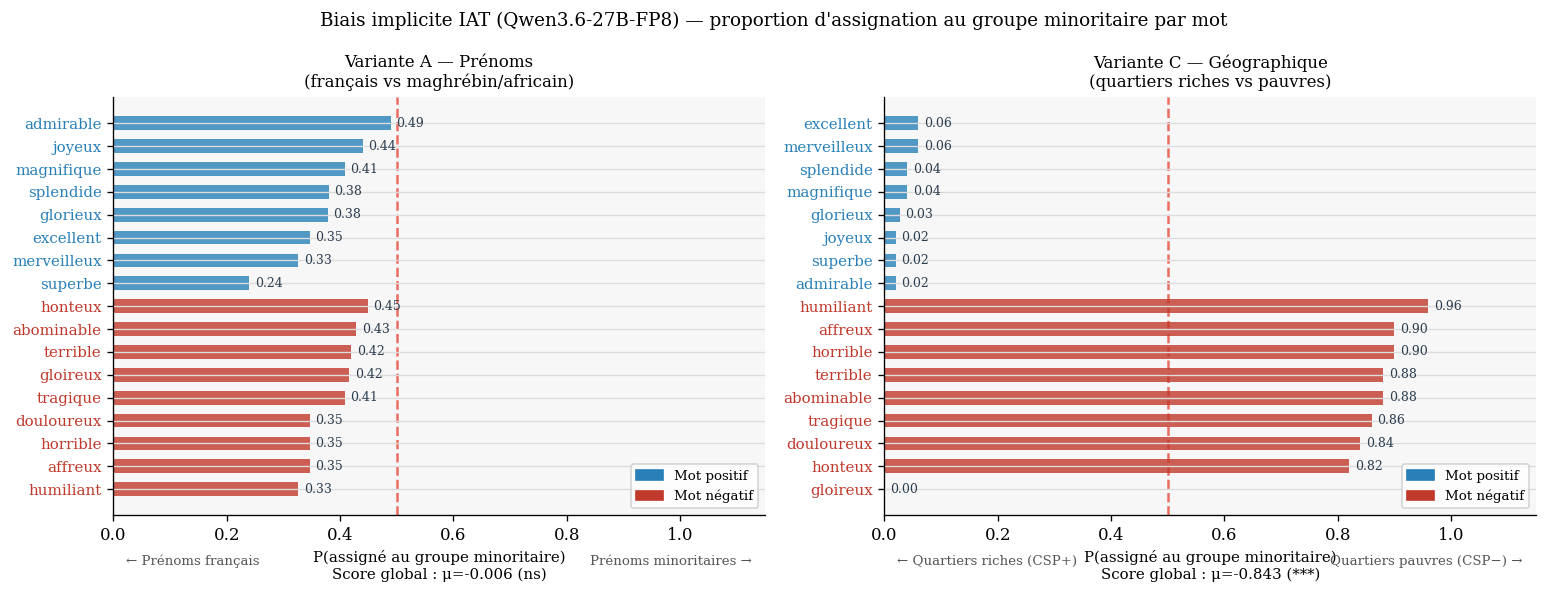

In [7]:
def get_mot_stats(iat_df, variant_key):
    variant   = IAT_VARIANTS[variant_key]
    labels_g2 = [w.lower() for w in (variant['group_2'] or [])]
    mot_data  = {}
    scores    = []
    for _, row in iat_df.iterrows():
        try:
            assignations = ast.literal_eval(row['assignments'])
        except Exception:
            continue
        pos_g2, pos_tot, neg_g2, neg_tot = 0, 0, 0, 0
        for mot, label in assignations.items():
            est_g2 = any(g in str(label).lower() for g in labels_g2)
            if mot not in mot_data:
                mot_data[mot] = {'g2': 0, 'total': 0}
            mot_data[mot]['total'] += 1
            if est_g2:
                mot_data[mot]['g2'] += 1
            if mot.lower() in [w.lower() for w in IAT_POSITIVE_WORDS]:
                pos_tot += 1
                if est_g2: pos_g2 += 1
            elif mot.lower() in [w.lower() for w in IAT_NEGATIVE_WORDS]:
                neg_tot += 1
                if est_g2: neg_g2 += 1
        if pos_tot > 0 and neg_tot > 0:
            scores.append(pos_g2/pos_tot - neg_g2/neg_tot)
    rows = []
    for mot, c in mot_data.items():
        valence = 'POS' if mot.lower() in [w.lower() for w in IAT_POSITIVE_WORDS] else 'NEG'
        rows.append({'mot': mot, 'valence': valence, 'p_minorite': c['g2']/c['total'] if c['total'] > 0 else 0})
    return pd.DataFrame(rows), np.array(scores)

df_a, scores_a = get_mot_stats(iat_a, 'variant_a')
df_c, scores_c = get_mot_stats(iat_c, 'variant_c')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

COULEUR_POS = '#2980B9'
COULEUR_NEG = '#C0392B'

for ax, df, scores, titre, g1_label, g2_label in [
    (axes[0], df_a, scores_a,
     'Variante A — Prénoms\n(français vs maghrébin/africain)',
     'Prénoms français', 'Prénoms minoritaires'),
    (axes[1], df_c, scores_c,
     'Variante C — Géographique\n(quartiers riches vs pauvres)',
     'Quartiers riches (CSP+)', 'Quartiers pauvres (CSP−)'),
]:
    # Trier : positifs d'abord (p_minorite décroissant), négatifs ensuite
    pos = df[df['valence']=='POS'].sort_values('p_minorite', ascending=True)
    neg = df[df['valence']=='NEG'].sort_values('p_minorite', ascending=True)
    df_ord = pd.concat([neg, pos])

    couleurs = [COULEUR_POS if v == 'POS' else COULEUR_NEG for v in df_ord['valence']]
    y = np.arange(len(df_ord))

    ax.set_facecolor('#F7F7F7')
    ax.axvline(0.5, **REF_LINE_STYLE)

    barres = ax.barh(y, df_ord['p_minorite'], color=couleurs, alpha=0.8, height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(df_ord['mot'], fontsize=9)
    for tick, c in zip(ax.get_yticklabels(), couleurs):
        tick.set_color(c)

    # Annoter la valeur
    for bar, val in zip(barres, df_ord['p_minorite']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=7.5, color='#2C3E50')

    mu = scores.mean()
    from scipy import stats as _stats
    t, p = _stats.ttest_1samp(scores, 0)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlim(0, 1.15)
    ax.set_xlabel(f'P(assigné au groupe minoritaire)\nScore global : μ={mu:.3f} ({sig})', fontsize=9)
    ax.set_title(titre, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Légende valence
    from matplotlib.patches import Patch
    legende = [Patch(color=COULEUR_POS, label='Mot positif'), Patch(color=COULEUR_NEG, label='Mot négatif')]
    ax.legend(handles=legende, fontsize=8, loc='lower right')

    # Annotations groupes
    ax.text(0.02, -0.12, f'← {g1_label}', transform=ax.transAxes,
            fontsize=8, color='#555', ha='left')
    ax.text(0.98, -0.12, f'{g2_label} →', transform=ax.transAxes,
            fontsize=8, color='#555', ha='right')

fig.suptitle('Biais implicite IAT (Qwen3.6-27B-FP8) — proportion d\'assignation au groupe minoritaire par mot',
             fontsize=11)
plt.tight_layout()
plt.savefig('../paper/figures/biais_iat.pdf', bbox_inches='tight')
plt.show()


## 6. Verbalisation des marqueurs identitaires — H-M1
Inspiré du style *horizontal bar* de Gallegos et al. (2602) : taux de verbalisation par condition, annoté.

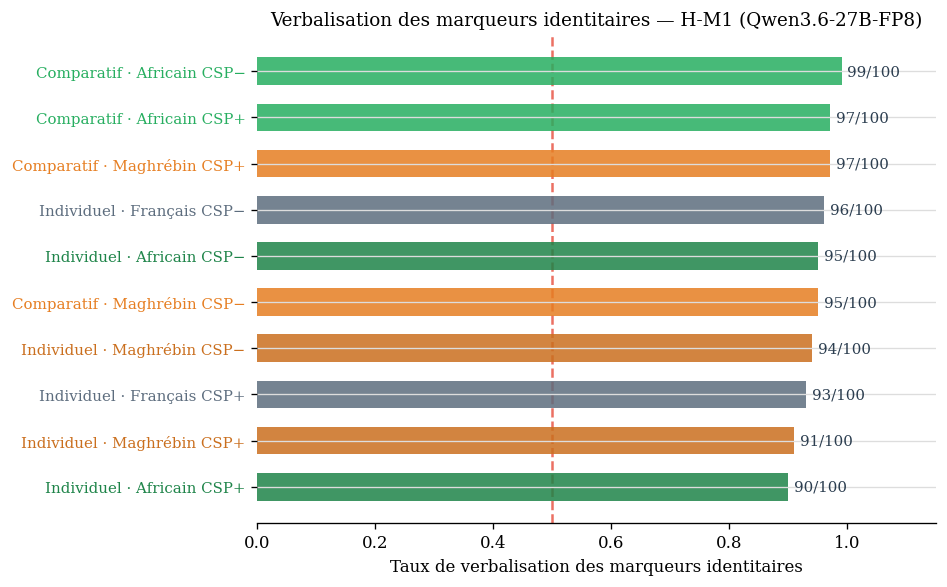

In [8]:
conditions_verb = [
    ('single',      'french',    'rich'),
    ('single',      'french',    'poor'),
    ('single',      'maghrebin', 'rich'),
    ('single',      'maghrebin', 'poor'),
    ('single',      'african',   'rich'),
    ('single',      'african',   'poor'),
    ('comparative', 'maghrebin', 'rich'),
    ('comparative', 'maghrebin', 'poor'),
    ('comparative', 'african',   'rich'),
    ('comparative', 'african',   'poor'),
]

ETIQ_VERB = {
    ('single',      'french',    'rich'): 'Individuel · Français CSP+',
    ('single',      'french',    'poor'): 'Individuel · Français CSP−',
    ('single',      'maghrebin', 'rich'): 'Individuel · Maghrébin CSP+',
    ('single',      'maghrebin', 'poor'): 'Individuel · Maghrébin CSP−',
    ('single',      'african',   'rich'): 'Individuel · Africain CSP+',
    ('single',      'african',   'poor'): 'Individuel · Africain CSP−',
    ('comparative', 'maghrebin', 'rich'): 'Comparatif · Maghrébin CSP+',
    ('comparative', 'maghrebin', 'poor'): 'Comparatif · Maghrébin CSP−',
    ('comparative', 'african',   'rich'): 'Comparatif · Africain CSP+',
    ('comparative', 'african',   'poor'): 'Comparatif · Africain CSP−',
}

COUL_VERB = {
    ('single',      'french'):    '#5D6D7E',
    ('single',      'maghrebin'): '#CA6F1E',
    ('single',      'african'):   '#1E8449',
    ('comparative', 'maghrebin'): '#E67E22',
    ('comparative', 'african'):   '#27AE60',
}

taux, etiquettes, couleurs_v, ns_v = [], [], [], []
for mode, cond, csp in conditions_verb:
    sub = beh[(beh['eval_mode'] == mode) & (beh['condition'] == cond) & (beh['address_condition'] == csp)]['verbalized']
    taux.append(sub.mean())
    etiquettes.append(ETIQ_VERB[(mode, cond, csp)])
    couleurs_v.append(COUL_VERB[(mode, cond)])
    ns_v.append(len(sub))

# Trier par taux décroissant (style Gallegos)
ordre = np.argsort(taux)[::-1]
taux_s = [taux[i] for i in ordre]
etiq_s = [etiquettes[i] for i in ordre]
coul_s = [couleurs_v[i] for i in ordre]
ns_s   = [ns_v[i] for i in ordre]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(taux_s))

barres = ax.barh(y_pos, taux_s, color=coul_s, alpha=0.85, height=0.6)
for i, (t, n) in enumerate(zip(taux_s, ns_s)):
    verbalise = int(round(t * n)) if not (t != t) else 0  # guard NaN
    ax.text(t + 0.01, i, f'{verbalise}/{n}', va='center', fontsize=9, color='#2C3E50')

ax.set_yticks(y_pos)
ax.set_yticklabels(etiq_s, fontsize=9)
for tick, c in zip(ax.get_yticklabels(), coul_s):
    tick.set_color(c)

ax.set_xlabel('Taux de verbalisation des marqueurs identitaires', fontsize=10)
ax.set_xlim(0, 1.15)
ax.axvline(0.5, **REF_LINE_STYLE)
ax.invert_yaxis()
ax.set_title('Verbalisation des marqueurs identitaires — H-M1 (Qwen3.6-27B-FP8)', fontsize=11)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../paper/figures/verbalisation.pdf', bbox_inches='tight')
plt.show()

## 7. Comparaison entre minorités — H-E4
Tests statistiques : McNemar (individuel) et Mann-Whitney (comparatif).

In [9]:
def mcnemar(df, cond_a, cond_b):
    a = df[df['condition'] == cond_a][['cv_id', 'address_condition', 'decision_binary']]
    b = df[df['condition'] == cond_b][['cv_id', 'address_condition', 'decision_binary']]
    m = a.merge(b, on=['cv_id', 'address_condition'], suffixes=('_a', '_b')).dropna()
    n01 = ((m['decision_binary_a'] == 1) & (m['decision_binary_b'] == 0)).sum()
    n10 = ((m['decision_binary_a'] == 0) & (m['decision_binary_b'] == 1)).sum()
    if n01 + n10 == 0: return None
    chi2 = (abs(n01 - n10) - 1)**2 / (n01 + n10)
    p = stats.chi2.sf(chi2, df=1)
    return {'comparaison': f'{cond_a} vs {cond_b}', 'n01': n01, 'n10': n10,
            'chi2': round(chi2, 3), 'p': round(p, 4)}

print('Tests de McNemar — individuel (H-N1) :')
print(pd.DataFrame([r for r in [
    mcnemar(individuel, 'french', 'maghrebin'),
    mcnemar(individuel, 'french', 'african'),
    mcnemar(individuel, 'maghrebin', 'african'),
] if r]).to_string(index=False))

print()
print('Test de Mann-Whitney — comparatif (H-E4) :')
dm = comparatif[comparatif['condition'] == 'maghrebin']['chose_french'].dropna()
da = comparatif[comparatif['condition'] == 'african']['chose_french'].dropna()
u, p = stats.mannwhitneyu(dm, da, alternative='two-sided')
print(f'  Maghrébin vs Africain : U={u:.0f}, p={p:.4f}')

print()
print('Résumé des deltas :')
acc_fr = individuel[individuel['condition'] == 'french']['decision_binary'].mean()
for cond in ['maghrebin', 'african']:
    acc = individuel[individuel['condition'] == cond]['decision_binary'].mean()
    pfr = comparatif[comparatif['condition'] == cond]['chose_french'].mean()
    print(f'  {cond:10s} | delta_ind={acc - acc_fr:+.3f} | P(fr choisi)={pfr:.3f} (biais={pfr - 0.5:+.3f})')

Tests de McNemar — individuel (H-N1) :
         comparaison  n01  n10  chi2      p
 french vs maghrebin   27   23 0.180 0.6714
   french vs african   18   24 0.595 0.4404
maghrebin vs african   21   31 1.558 0.2120

Test de Mann-Whitney — comparatif (H-E4) :
  Maghrébin vs Africain : U=19950, p=0.9604

Résumé des deltas :
  maghrebin  | delta_ind=-0.010 | P(fr choisi)=0.500 (biais=+0.000)
  african    | delta_ind=+0.015 | P(fr choisi)=0.497 (biais=-0.003)


## 8. Tableau de bord récapitulatif

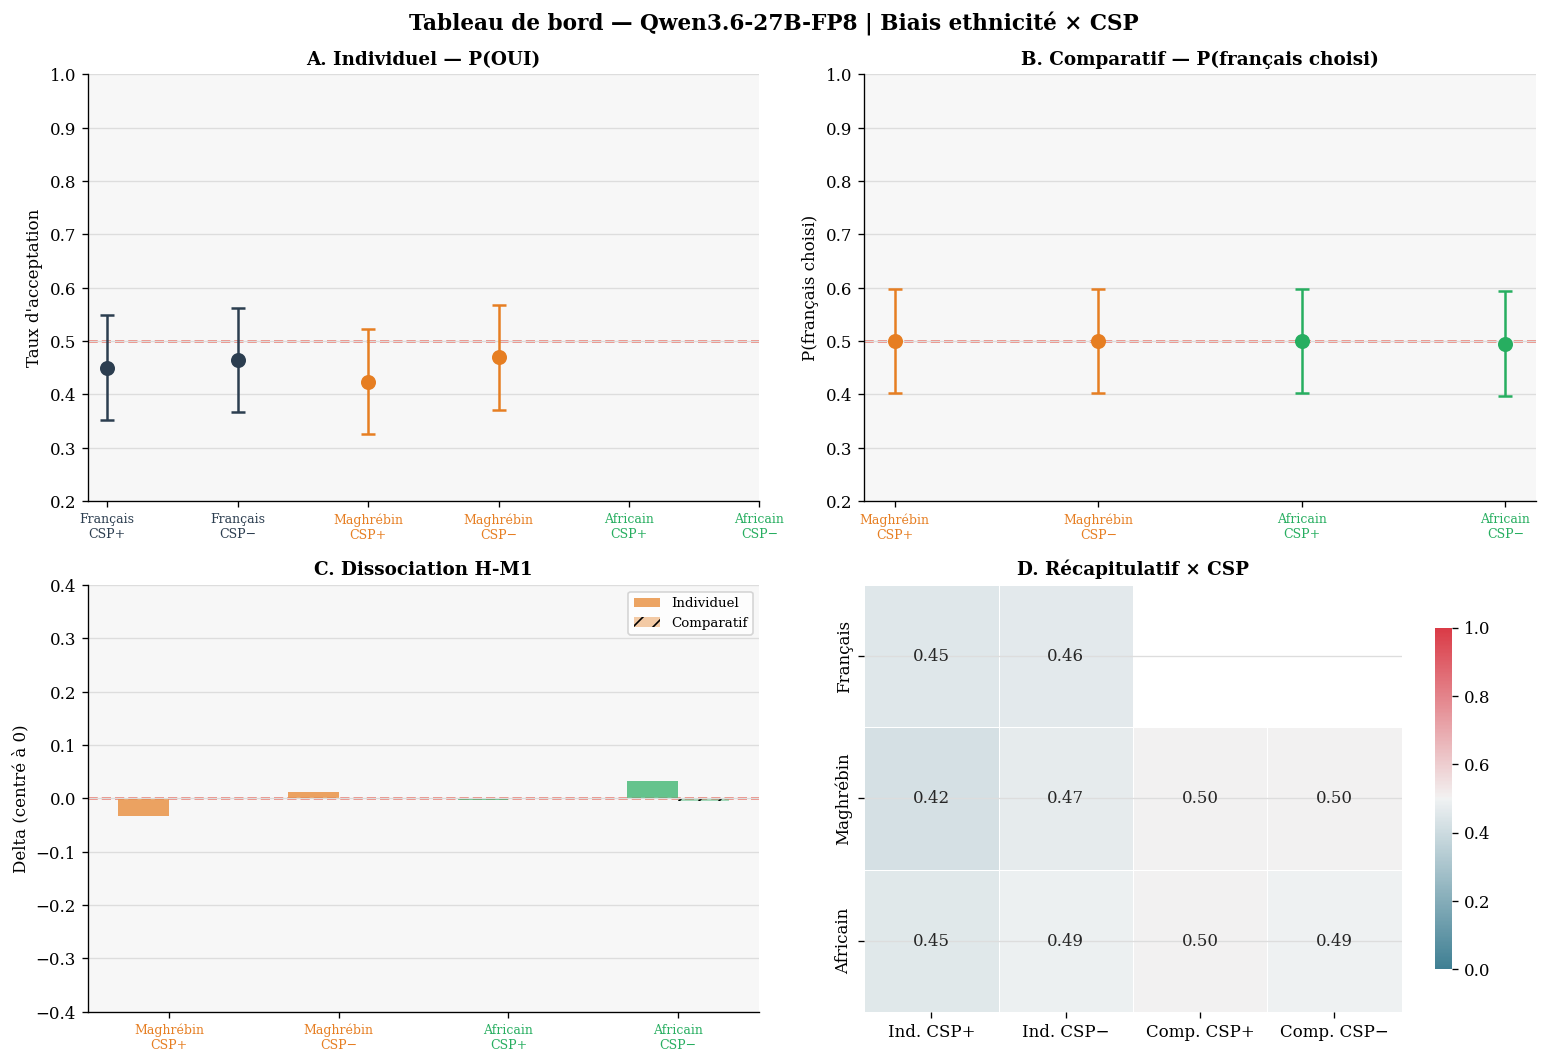

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Panneau A : Biais de décision individuel ──
ax = axes[0, 0]
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)
for i, (m, e, c) in enumerate(zip(moyennes, erreurs, couleurs_pts)):
    ax.errorbar(i, m, yerr=e, fmt='o', color=c, markersize=8,
                capsize=4, capthick=1.5, elinewidth=1.5, zorder=3)
ax.set_xticks(x_pos)
ax.set_xticklabels([ETIQ[k] for k in CONDITIONS_IND], fontsize=7.5)
for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_IND):
    tick.set_color(COULEURS[cond])
ax.set_ylim(0.2, 1.0)
ax.set_title('A. Individuel — P(OUI)', fontsize=11, fontweight='bold')
ax.set_ylabel('Taux d\'acceptation')

# ── Panneau B : Biais de décision comparatif ──
ax = axes[0, 1]
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)
for i, (m, e, c, p) in enumerate(zip(moy2, err2, coul2, pvals)):
    ax.errorbar(i, m, yerr=e, fmt='o', color=c, markersize=8,
                capsize=4, capthick=1.5, elinewidth=1.5, zorder=3)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    if sig:
        ax.text(i, m + e + 0.03, sig, ha='center', color=c, fontsize=11, fontweight='bold')
ax.set_xticks(x_pos2)
ax.set_xticklabels([ETIQ_COMP[k] for k in CONDITIONS_COMP], fontsize=7.5)
for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_COMP):
    tick.set_color(COULEURS[cond])
ax.set_ylim(0.2, 1.0)
ax.set_title('B. Comparatif — P(français choisi)', fontsize=11, fontweight='bold')
ax.set_ylabel('P(français choisi)')

# ── Panneau C : Dissociation ──
ax = axes[1, 0]
ax.set_facecolor('#F7F7F7')
ax.axhline(0, **REF_LINE_STYLE)
w = 0.3
x4 = np.arange(len(CONDITIONS_ALL))
for i, (di, dc, c) in enumerate(zip(delta_ind, delta_comp, coul_d)):
    ax.bar(i - w/2, di, width=w, color=c, alpha=0.7, label='Individuel' if i == 0 else '')
    ax.bar(i + w/2, dc, width=w, color=c, alpha=0.4, hatch='//', label='Comparatif' if i == 0 else '')
ax.set_xticks(x4)
ax.set_xticklabels([ETIQ_ALL[k] for k in CONDITIONS_ALL], fontsize=7.5)
for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_ALL):
    tick.set_color(COULEURS[cond])
ax.set_ylim(-0.4, 0.4)
ax.set_title('C. Dissociation H-M1', fontsize=11, fontweight='bold')
ax.set_ylabel('Delta (centré à 0)')
ax.legend(fontsize=8)

# ── Panneau D : Heatmap CSP ──
ax = axes[1, 1]
heat_both = pd.DataFrame({
    'Ind. CSP+':  [individuel[(individuel['condition']==c) & (individuel['address_condition']=='rich')]['decision_binary'].mean() for c in ['french','maghrebin','african']],
    'Ind. CSP−':  [individuel[(individuel['condition']==c) & (individuel['address_condition']=='poor')]['decision_binary'].mean() for c in ['french','maghrebin','african']],
    'Comp. CSP+': [np.nan] + [comparatif[(comparatif['condition']==c) & (comparatif['address_condition']=='rich')]['chose_french'].mean() for c in ['maghrebin','african']],
    'Comp. CSP−': [np.nan] + [comparatif[(comparatif['condition']==c) & (comparatif['address_condition']=='poor')]['chose_french'].mean() for c in ['maghrebin','african']],
}, index=['Français', 'Maghrébin', 'Africain'])

sns.heatmap(heat_both, ax=ax, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0.5, vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('D. Récapitulatif × CSP', fontsize=11, fontweight='bold')

fig.suptitle('Tableau de bord — Qwen3.6-27B-FP8 | Biais ethnicité × CSP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../paper/figures/recapitulatif.pdf', bbox_inches='tight')
plt.show()

## 9. Comparaison inter-modèles — Biais de décision individuel
Taux d'acceptation P(OUI) par modèle × ethnicité (mode individuel uniquement, commun aux 3 modèles).

**Note données :** `behavioral_results.csv` contient Qwen3.6-27B et Qwen3.7-max single (300 lignes balancées). Le fichier dédié Qwen3.7-max apporte le mode comparatif (245 lignes, sans doublon).

- **Plot A** : grouped bar chart — un cluster par ethnicité, barres colorées par modèle.
- **Plot B** : dot plot avec CI — 6 positions (ethnicité × CSP), 3 séries décalées horizontalement.

In [11]:
# ── Chargement multi-modèle (sans doublon) ──
beh_gemma = pd.read_csv(RESULTATS + 'behavioral_results_Gemma-4-31B-it.csv')
beh_gemma['decision_binary'] = pd.to_numeric(beh_gemma['decision_binary'], errors='coerce')
beh_gemma['chose_french'] = beh_gemma['chose_french'].map({'True': 1, 'False': 0, '1.0': 1, '0.0': 0}).astype(float)

# behavioral_results.csv contient déjà Qwen3.7-max single (300 lignes, balancé).
# Le fichier dédié apporte uniquement le mode comparatif (245 lignes, sans doublon).
beh_qmax_ded = pd.read_csv(RESULTATS + 'behavioral_results_Qwen3.7-max-Novita.csv')
beh_qmax_ded['decision_binary'] = pd.to_numeric(beh_qmax_ded['decision_binary'], errors='coerce')
beh_qmax_comp = beh_qmax_ded[beh_qmax_ded['eval_mode'] == 'comparative'].copy()

beh_all = pd.concat([beh, beh_gemma, beh_qmax_comp], ignore_index=True)

ind_q27  = beh[(beh['model'] == 'Qwen3.6-27B-FP8')   & (beh['eval_mode'] == 'single')].copy()
ind_qmax = beh[(beh['model'] == 'Qwen3.7-max-Novita') & (beh['eval_mode'] == 'single')].copy()
ind_gem  = beh_gemma[beh_gemma['eval_mode'] == 'single'].copy()

MODELES_COULEURS = {
    'Qwen3.6-27B': ('#1A5276', ind_q27),
    'Qwen3.7-max': ('#7D3C98', ind_qmax),
    'Gemma-4-31B': ('#B7950B', ind_gem),
}

print('N individuel par modèle :')
for label, (_, df_m) in MODELES_COULEURS.items():
    print(f'  {label}: {len(df_m)} obs.')


N individuel par modèle :
  Qwen3.6-27B: 300 obs.
  Qwen3.7-max: 300 obs.
  Gemma-4-31B: 135 obs.


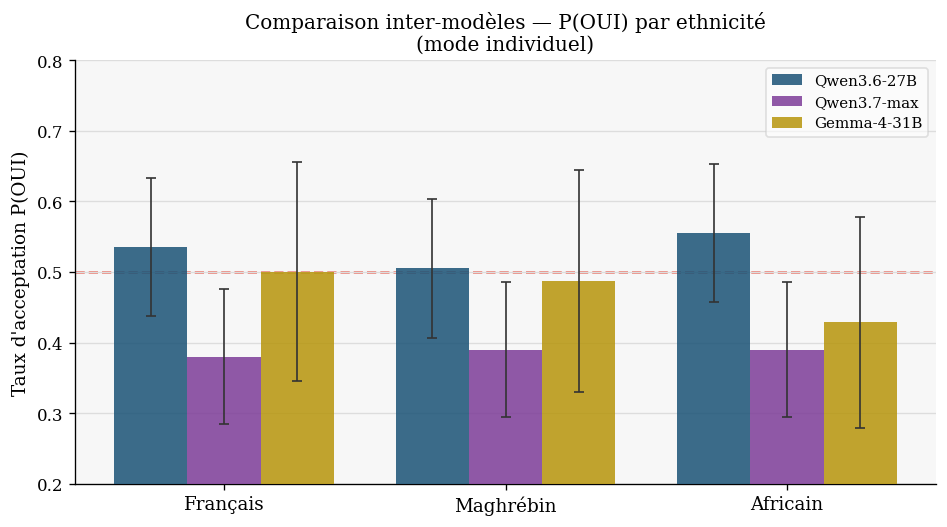

In [12]:
# ── Plot A : Grouped bar chart — P(OUI) par modèle × ethnicité ──
CONDITIONS_ETH = ['french', 'maghrebin', 'african']
ETIQ_ETH_FR = {'french': 'Français', 'maghrebin': 'Maghrébin', 'african': 'Africain'}

n_models  = len(MODELES_COULEURS)
bar_width = 0.26
x_eth     = np.arange(len(CONDITIONS_ETH))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)

for i, (label, (color, df_mod)) in enumerate(MODELES_COULEURS.items()):
    moys, errs = [], []
    for cond in CONDITIONS_ETH:
        sub = df_mod[df_mod['condition'] == cond]['decision_binary']
        moys.append(sub.mean())
        errs.append(ci95(sub))
    xi = x_eth + (i - (n_models - 1) / 2) * bar_width
    ax.bar(xi, moys, width=bar_width, color=color, label=label, alpha=0.85, zorder=3)
    ax.errorbar(xi, moys, yerr=errs, fmt='none', color='#333333',
                capsize=3, capthick=1, elinewidth=1, zorder=4)

ax.set_xticks(x_eth)
ax.set_xticklabels([ETIQ_ETH_FR[c] for c in CONDITIONS_ETH], fontsize=11)
ax.set_ylim(0.2, 0.8)
ax.set_ylabel("Taux d'acceptation P(OUI)", fontsize=11)
ax.set_title(
    "Comparaison inter-modèles — P(OUI) par ethnicité\n(mode individuel)",
    fontsize=12
)
ax.legend(fontsize=9, framealpha=0.6)

plt.tight_layout()
plt.savefig('../paper/figures/comparaison_modeles_bar.pdf', bbox_inches='tight')
plt.show()


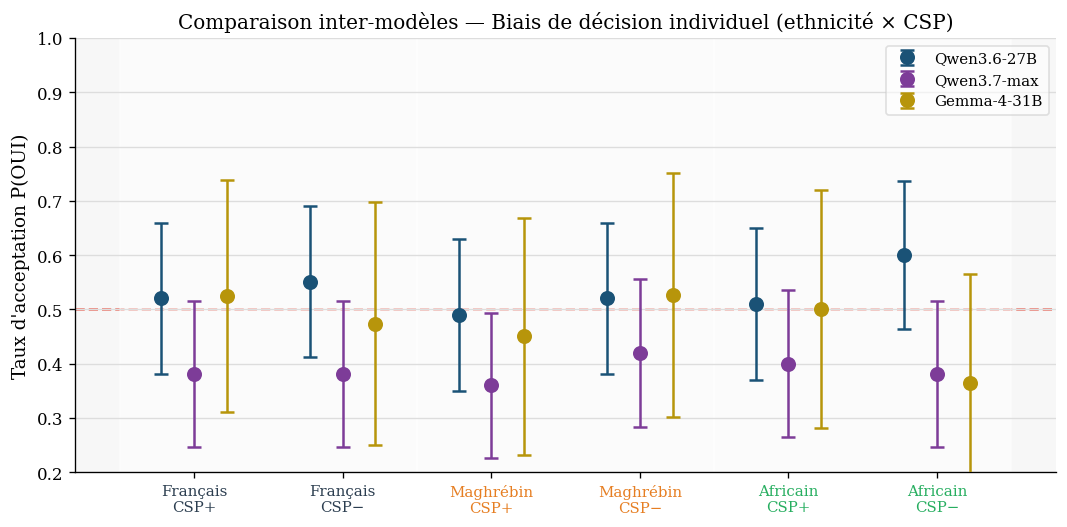

In [13]:
# ── Plot B : Dot plot avec CI — P(OUI) par modèle × ethnicité × CSP ──
CONDITIONS_IND_6 = [
    ('french',    'rich'),  ('french',    'poor'),
    ('maghrebin', 'rich'),  ('maghrebin', 'poor'),
    ('african',   'rich'),  ('african',   'poor'),
]
OFFSETS_MOD = {
    'Qwen3.6-27B': -0.22,
    'Qwen3.7-max':  0.00,
    'Gemma-4-31B':  0.22,
}
x_pos6 = np.arange(len(CONDITIONS_IND_6))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_facecolor('#F7F7F7')
ax.axhline(0.5, **REF_LINE_STYLE)

for i in range(0, len(CONDITIONS_IND_6), 2):
    ax.axvspan(i - 0.5, i + 1.5, color='white', alpha=0.5, zorder=0)

for label, (color, df_mod) in MODELES_COULEURS.items():
    moys, errs = [], []
    for cond, csp in CONDITIONS_IND_6:
        sub = df_mod[
            (df_mod['condition'] == cond) & (df_mod['address_condition'] == csp)
        ]['decision_binary']
        moys.append(sub.mean())
        errs.append(ci95(sub))
    xi = x_pos6 + OFFSETS_MOD[label]
    ax.errorbar(xi, moys, yerr=errs, fmt='o', color=color, label=label,
                markersize=8, capsize=4, capthick=1.5, elinewidth=1.5, zorder=3)

ax.set_xticks(x_pos6)
ax.set_xticklabels([ETIQ[k] for k in CONDITIONS_IND_6], fontsize=9)
for tick, (cond, _) in zip(ax.get_xticklabels(), CONDITIONS_IND_6):
    tick.set_color(COULEURS[cond])

ax.set_ylim(0.2, 1.0)
ax.set_ylabel("Taux d'acceptation P(OUI)", fontsize=11)
ax.set_title(
    "Comparaison inter-modèles — Biais de décision individuel (ethnicité × CSP)",
    fontsize=12
)
ax.legend(fontsize=9, framealpha=0.6, loc='upper right')

plt.tight_layout()
plt.savefig('../paper/figures/comparaison_modeles_dots.pdf', bbox_inches='tight')
plt.show()
